# Figure 2
This notebook is meant to be a reproducible implementation of the plotting leading to the complete figure 2 of the article. Saving of the necessary data to plot in .csv format is also provided.

In [38]:
# Import packages
from pathlib import Path
import os 
import re
import matplotlib.pyplot as plt
import pandas as pd

### Load general information

In [222]:
from dmt_hypnodensities import load_config

config_path = next(
    path.resolve()
    for path in (Path("configs/analysis.yaml"), Path("../configs/analysis.yaml"))
    if path.is_file()
)

config = load_config(config_path)

# Get start and end of each experimental window (pre-infusion, infusion and post-infusion) and convert to minutes for plotting
experimental_windows_min = {
    window.label: (window.start/60, window.end/60) for window in config.experimental_windows
    }

# Set hypnodensity and spectra data directory
hypnodensity_and_spectra_outputs = "D:/DMT_data/last results/02_hypnodensity_psd_000s/outputs/gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1/recordings"

# Get files lists and subject IDs
files_list = os.listdir(hypnodensity_and_spectra_outputs)

subjects_hypnodensities = sorted({
    match.group(1)
    for f in files_list
    if (match := re.search(r"(P\d+)D\d+_inner_hypnodensities\.parquet$", f))
})
subjects_spectra = sorted({
    match.group(1)
    for f in files_list
    if (match := re.search(r"(P\d+)D\d+_inner_spectra\.parquet$", f))
})
assert subjects_hypnodensities == subjects_spectra, "Mismatch between hypnodensity and spectra subjects"

subjects = subjects_hypnodensities
del subjects_hypnodensities, subjects_spectra

# Set output directory
output_dir = config.output_dir

plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

### Fig 2. a. Example hypnodensity graph of DMT and Placebo sessions for the same subject

### Debugging

In [ ]:
# Load data for one subject (P09) and one session (D5, which is DMT)
hypnodensity_and_spectra_outputs = "D:/DMT_data/last results/02_hypnodensity_psd_000s/outputs/gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1/recordings"
recordings_dir = Path(hypnodensity_and_spectra_outputs)
subject = 'P09'
condition = 'DMT' 
stages = ("W", "R", "N1", "N2", "N3")
max_time_seconds = 3540

matches = []
selected_session = 'D5'

matches = sorted(recordings_dir.glob(f'*{subject}{selected_session}*_hypnodensities.parquet'))

data = pd.read_parquet(matches[0])
print(f"Data shape: {data.shape}")

Data shape: (3456, 24)


In [65]:
data

,recording_id,subject,session,condition,block_id,epoch,stager,channel_set,electrode,el_10-20,...,prob_R,stage,continuous_run_id,epoch_in_run,break_before,gap_before_seconds,absolute_start,absolute_end,experimental_label,channel_set_10-20
0,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B000,0,gssc,E144,E144,C2,...,0.017054,W,DMTCI_P09D5_inner__R0002,0,False,NaN,13.002,43.000,outside,C2
1,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B000,1,gssc,E144,E144,C2,...,0.003108,W,DMTCI_P09D5_inner__R0002,1,False,0.0,43.002,73.000,outside,C2
2,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B000,2,gssc,E144,E144,C2,...,0.005350,W,DMTCI_P09D5_inner__R0002,2,False,0.0,73.002,103.000,outside,C2
3,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B000,0,gssc,E53,E53,C1,...,0.023844,W,DMTCI_P09D5_inner__R0002,0,False,NaN,13.002,43.000,outside,C1
4,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B000,1,gssc,E53,E53,C1,...,0.010022,W,DMTCI_P09D5_inner__R0002,1,False,0.0,43.002,73.000,outside,C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B024,0,sleepfm,E129,E129,P2,...,0.115194,N2,DMTCI_P09D5_inner__R0294,0,False,NaN,3905.916,3935.914,outside,P2
3452,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B024,0,sleepfm,E116,E116,O1,...,0.129657,N2,DMTCI_P09D5_inner__R0294,0,False,NaN,3905.916,3935.914,outside,O1
3453,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B024,0,sleepfm,E119,E119,POz,...,0.138696,N2,DMTCI_P09D5_inner__R0294,0,False,NaN,3905.916,3935.914,outside,POz
3454,DMTCI_P09D5_inner,P09,D5,DMT,DMTCI_P09D5_inner__B024,0,sleepfm,E115,E115,PO7,...,0.120535,N2,DMTCI_P09D5_inner__R0294,0,False,NaN,3905.916,3935.914,outside,PO7


In [66]:
# Keep only the rows where the absolute_start is between 0 and max_time_seconds
data.loc[data['absolute_start'].between(0, max_time_seconds)]
print("Data shape after filtering for max_time_seconds:", data.shape)

probability_columns = [f'prob_{stage}' for stage in stages]


Data shape after filtering for max_time_seconds: (3456, 24)


In [67]:
probability_columns

['prob_W', 'prob_R', 'prob_N1', 'prob_N2', 'prob_N3']

In [99]:
trajectory = (
    data
    .groupby('absolute_start', as_index=False)[probability_columns]
    .mean()
    .sort_values('absolute_start')
)
trajectory['time_min'] = trajectory['absolute_start'] / 60

### Main script

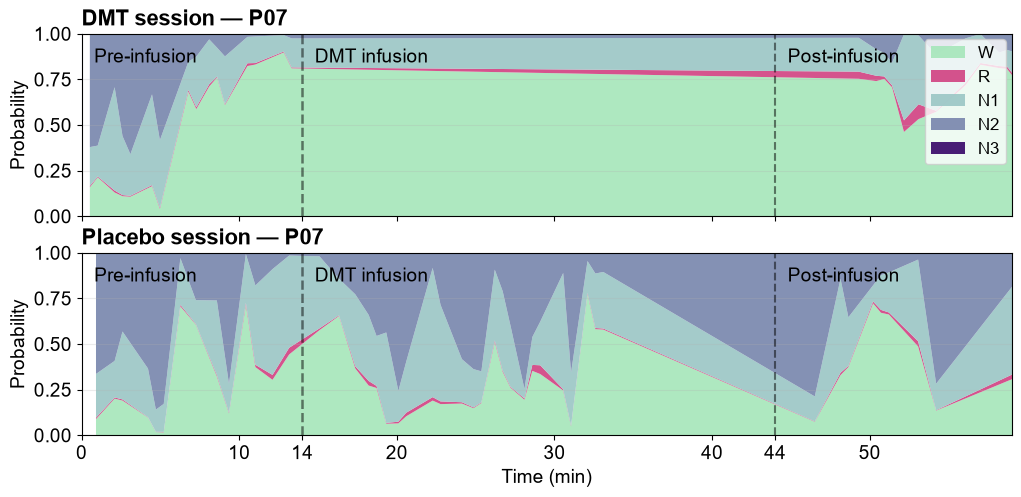

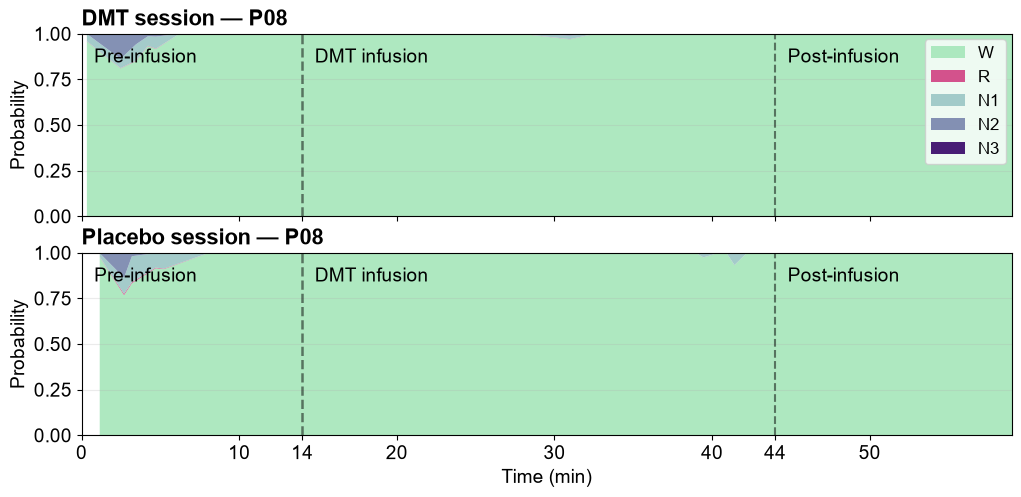

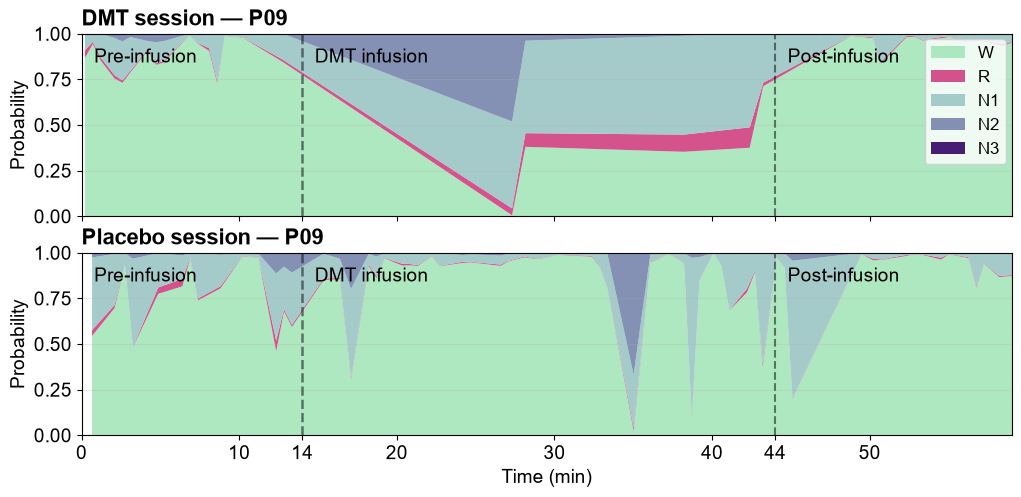

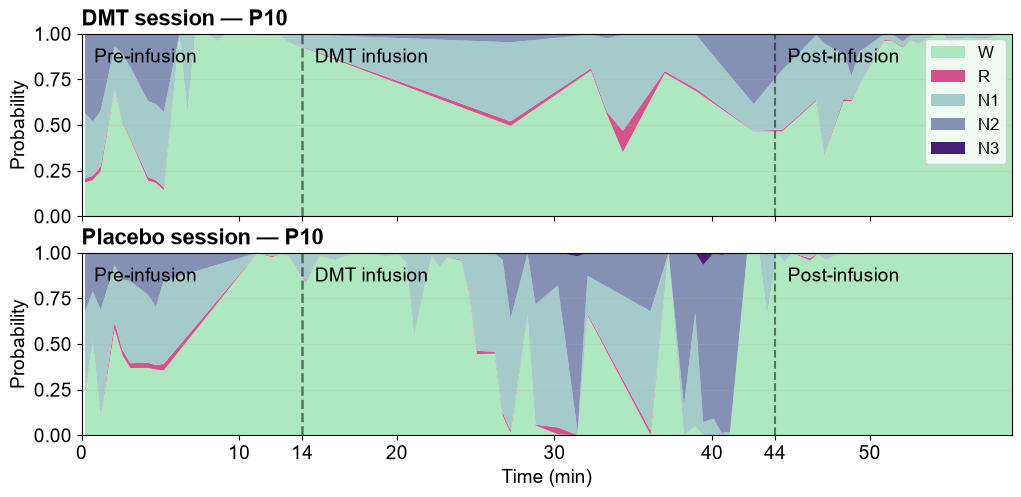

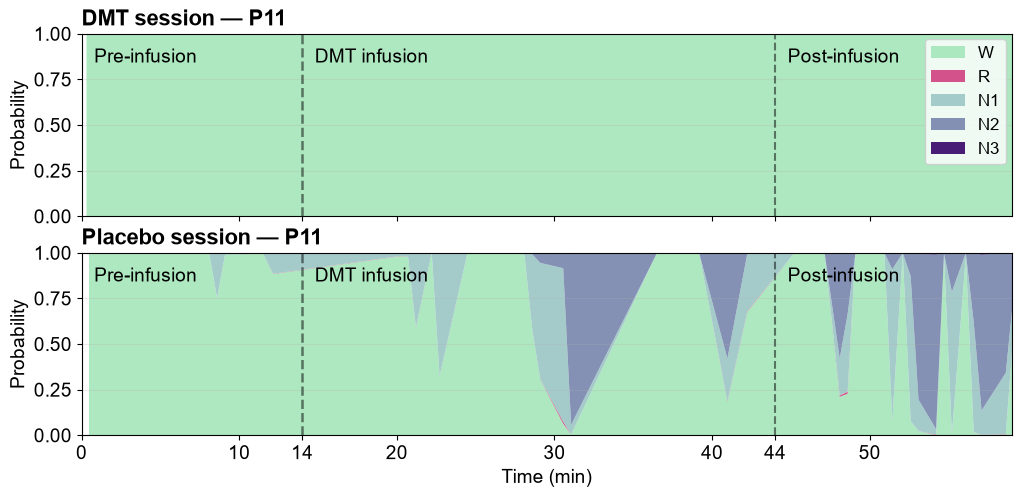

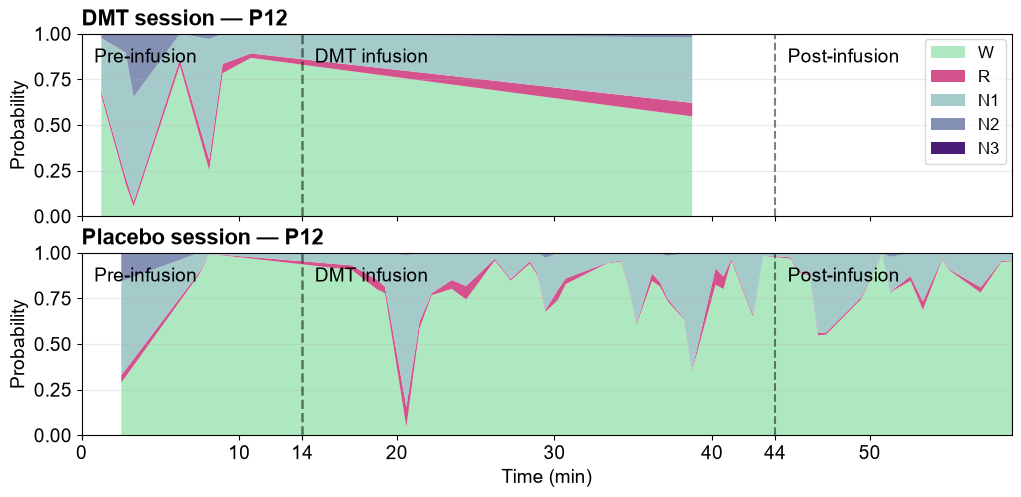

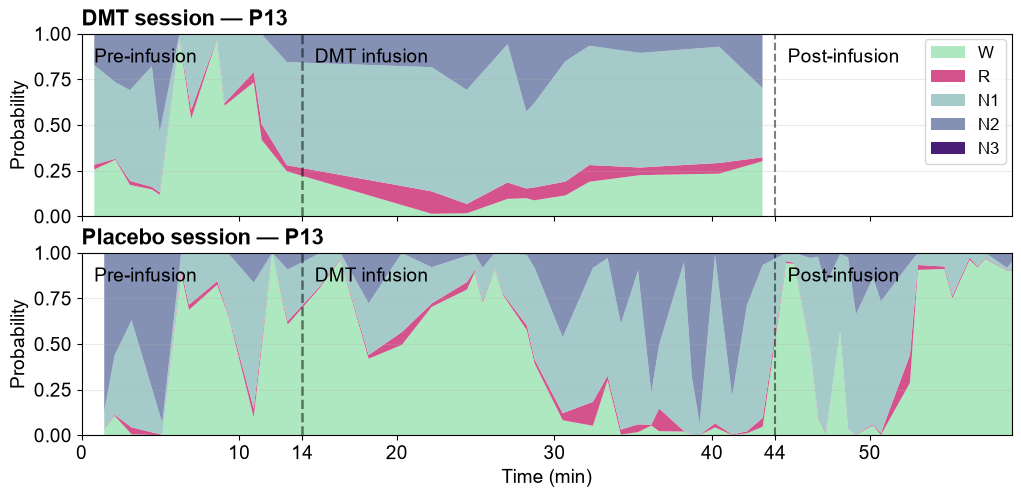

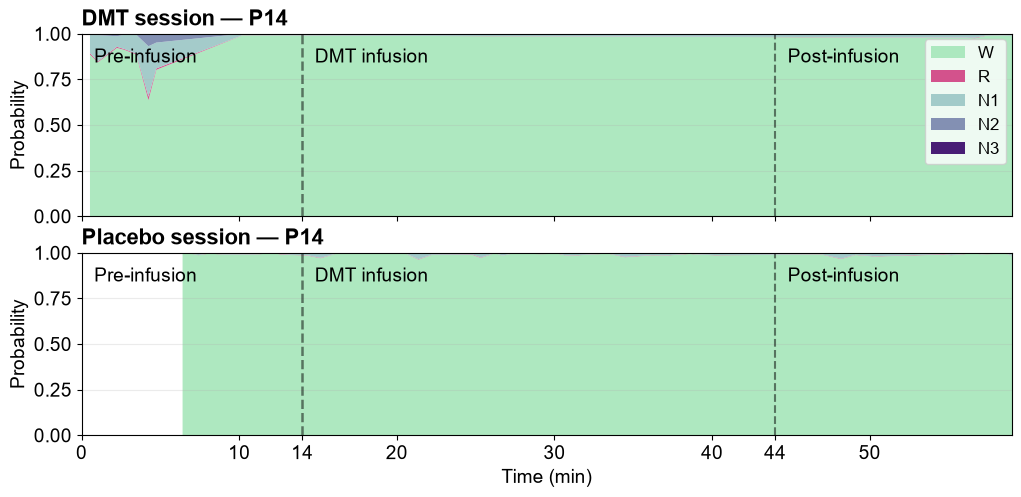

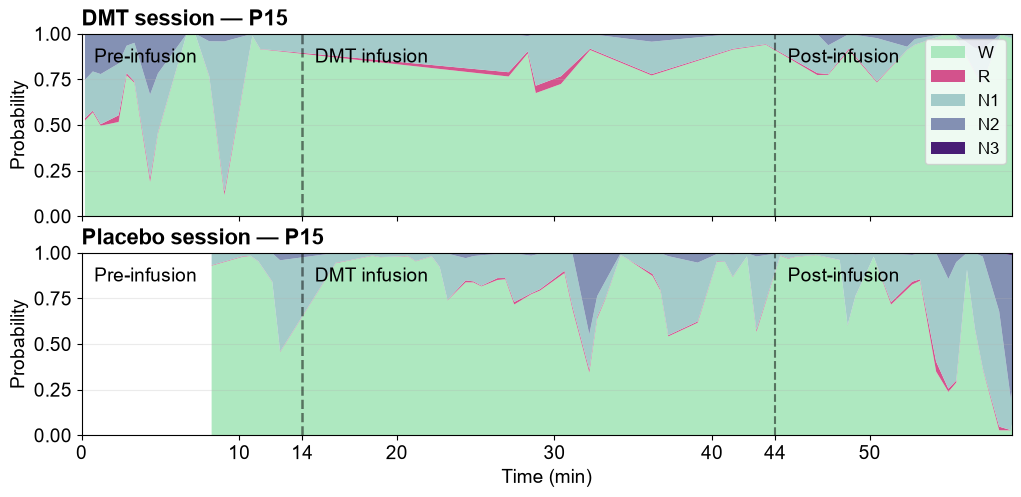

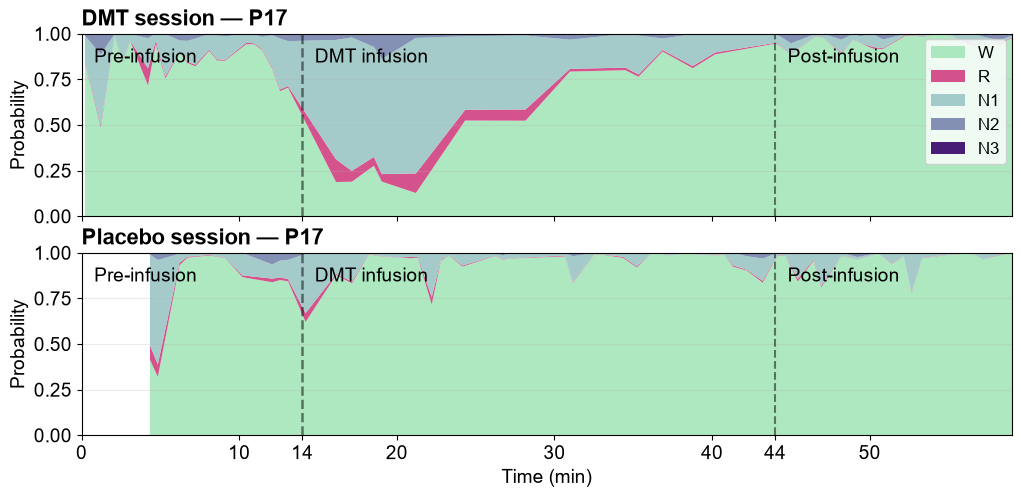

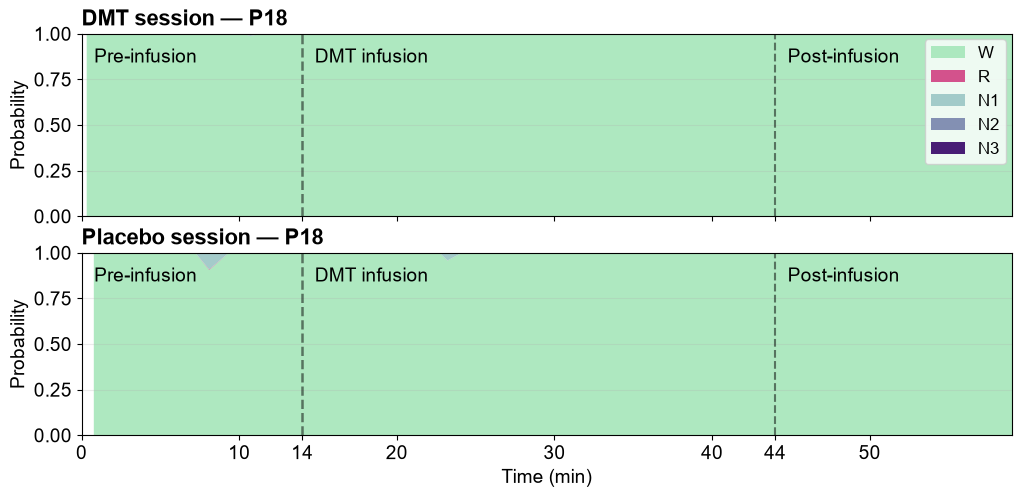

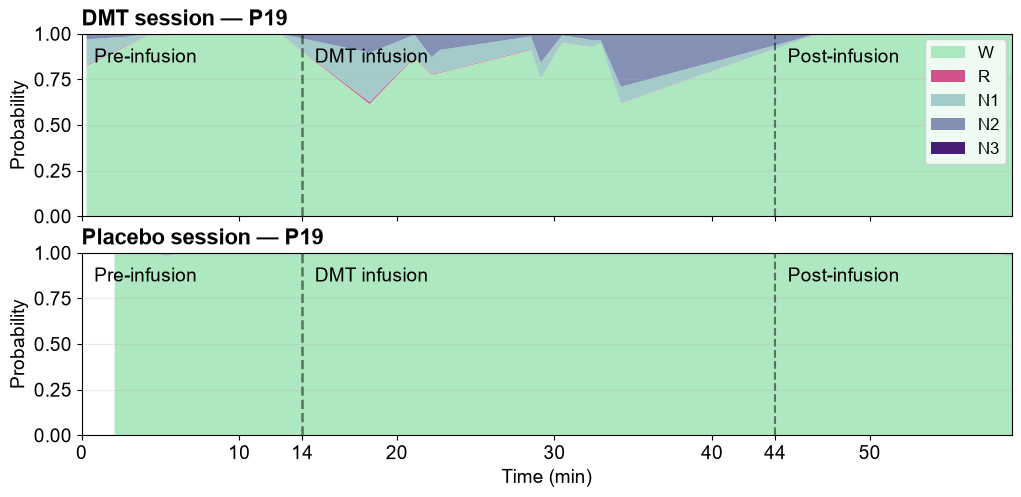

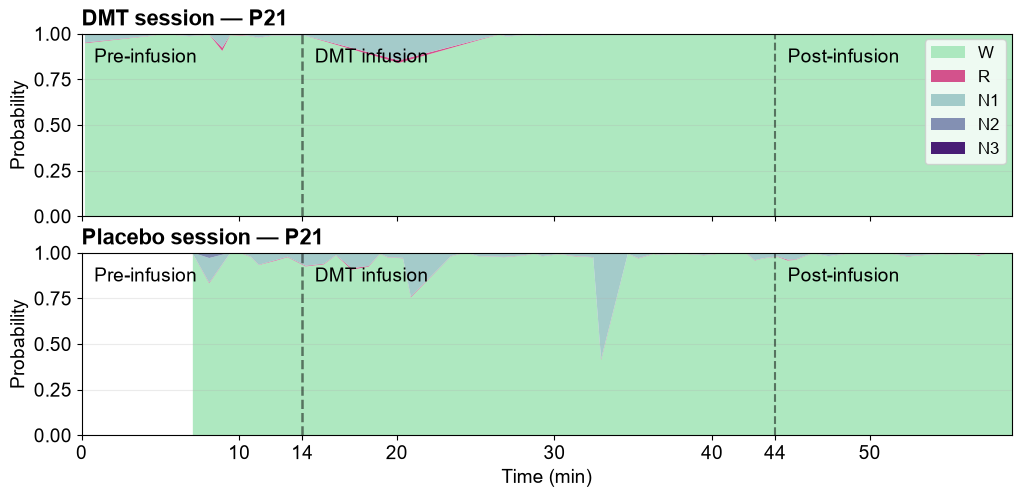

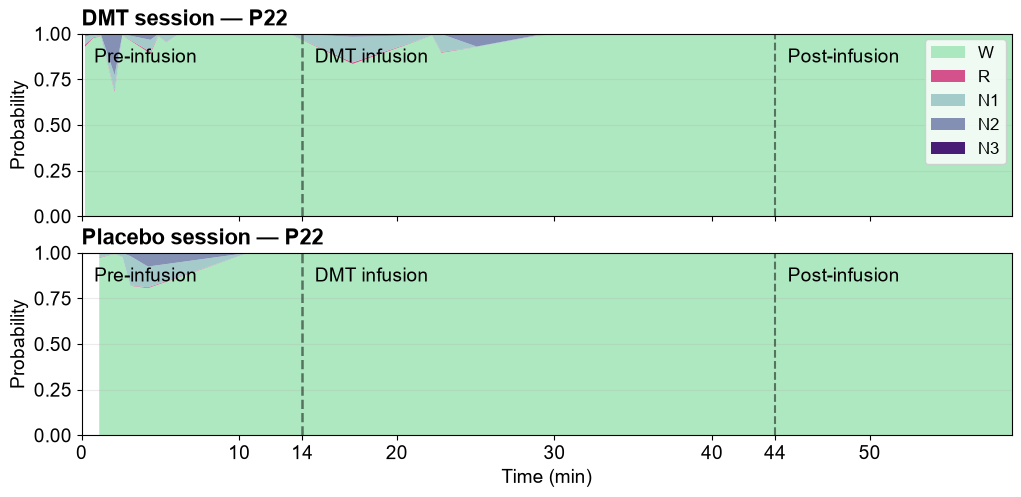

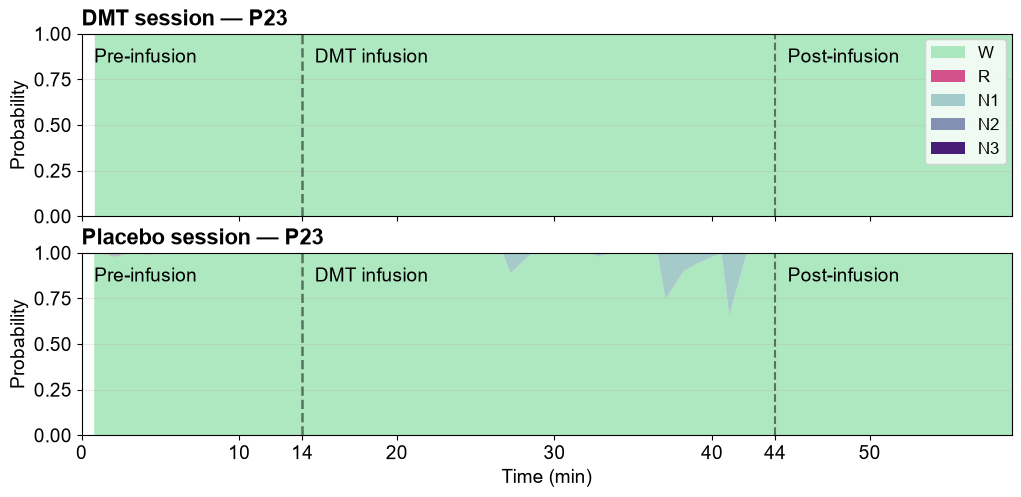

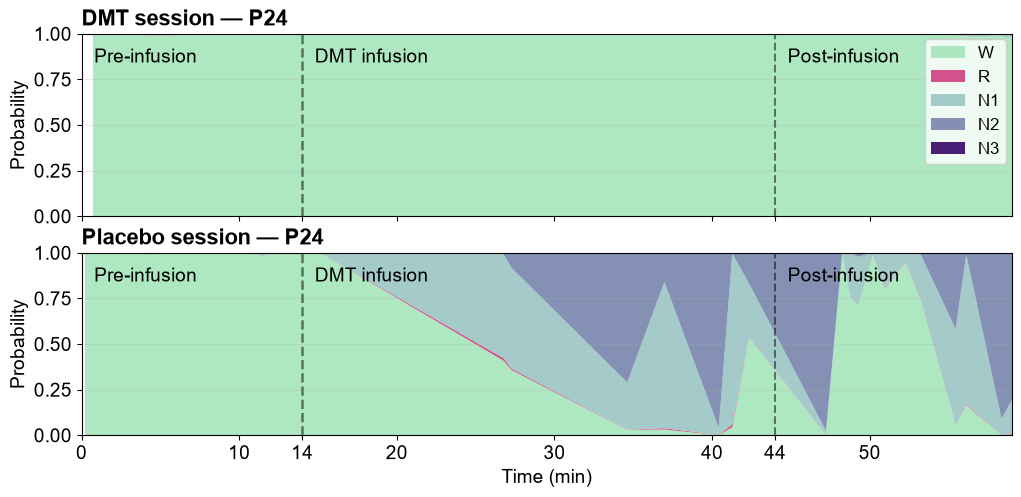

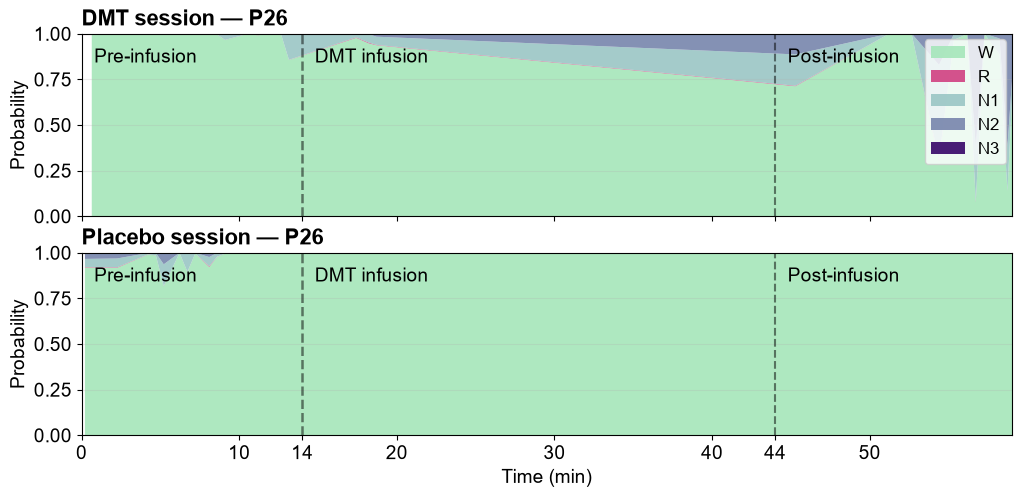

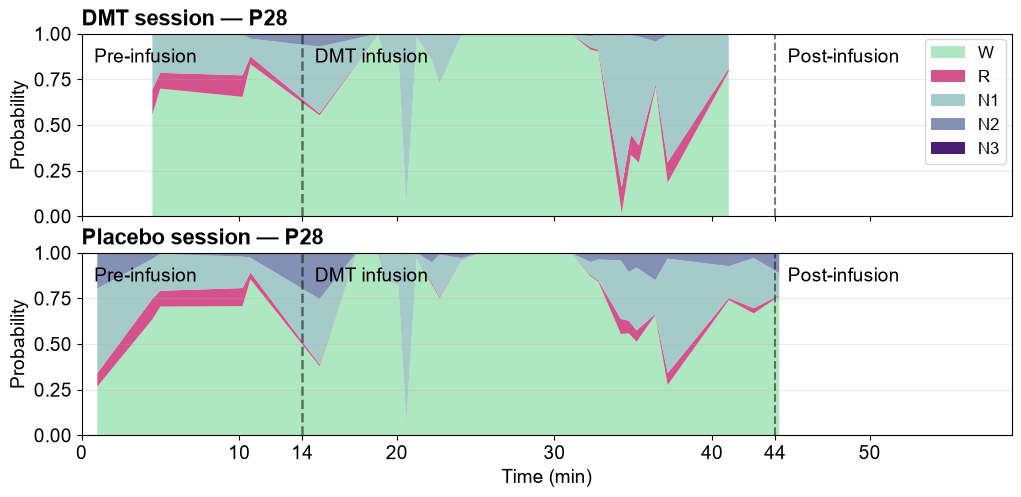

Figure data saved to: D:\DMT_data\last results\02_hypnodensity_psd_000s\outputs\gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1\figure2a_hypnodensity_plot_data.csv


,subject,condition,session,recording_id,stager,electrode_selection,absolute_start,time_min,prob_W,prob_R,prob_N1,prob_N2,prob_N3
0,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,31.686,0.528100,0.158508,0.007267,0.213002,0.621042,0.000181
1,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,61.686,1.028100,0.213033,0.004734,0.169222,0.612364,0.000647
2,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,126.002,2.100033,0.130181,0.010597,0.566149,0.293006,0.000067
3,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,156.002,2.600033,0.109755,0.006022,0.323526,0.560461,0.000237
4,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,186.002,3.100033,0.107020,0.004788,0.227891,0.658381,0.001920


In [ ]:
subject = 'P09'
# D5 is preferred for DMT; D2 is used automatically when D5 is unavailable.
sessions_by_condition = {'placebo': ('D1',), 'DMT': ('D5', 'D2')}
STAGER = 'gssc'
electrode = None  # e.g. 'Cz'; None averages the selected stager across electrodes
stages = ("W", "R", "N1", "N2", "N3")
palette = ["#360568", "#7785ac", "#9ac6c5",  "#d14081", "#a5e6ba"]
palette.reverse()
colors = dict(zip(stages, palette))

recordings_dir = Path(hypnodensity_and_spectra_outputs)
if not recordings_dir.is_dir():
    raise FileNotFoundError(f'Recordings directory not found: {recordings_dir}')

def load_session_hypnodensity(condition, sessions):
    matches = []
    selected_session = None
    for session in sessions:
        matches = sorted(recordings_dir.glob(f'*{subject}{session}*_hypnodensities.parquet'))
        if len(matches) == 1:
            selected_session = session
            break
        if len(matches) > 1:
            raise FileNotFoundError(
                f'Expected one {condition} file for {subject}{session}; found: {matches}'
            )
    if selected_session is None:
        attempted = ', '.join(f'{subject}{session}' for session in sessions)
        raise FileNotFoundError(f'No {condition} hypnodensity file found; tried: {attempted}')

    data = pd.read_parquet(matches[0])
    required = {'condition', 'stager', 'absolute_start', *(f'prob_{stage}' for stage in stages)}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f'{matches[0].name} is missing columns: {sorted(missing)}')
    if set(data['condition'].dropna().unique()) != {condition}:
        raise ValueError(f'{matches[0].name} does not contain the expected {condition} session.')

    data = data.loc[data['stager'].astype(str).str.lower().eq(STAGER)].copy()
    if electrode is not None:
        data = data.loc[data['electrode'].eq(electrode)].copy()
    if data.empty:
        raise ValueError(f'No {STAGER} hypnodensities available for {subject} {condition}.')

    probability_columns = [f'prob_{stage}' for stage in stages]
    # One trace per stage: average repeated per-electrode predictions at each epoch.
    trajectory = (
        data
        .groupby('absolute_start', as_index=False)[probability_columns]
        .mean()
        .sort_values('absolute_start')
    )
    trajectory['time_min'] = trajectory['absolute_start'] / 60
    return trajectory, matches[0].stem.removesuffix('_hypnodensities'), selected_session

# Store the exact trajectories used in the figures, for standalone CSV export.
figure_data = []

for subject in subjects:
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True, sharey=True)
    for axis, condition in zip(axes, ('DMT', 'placebo')):
        trajectory, recording_id, session = load_session_hypnodensity(
            condition, sessions_by_condition[condition]
        )
        figure_data.append(
            trajectory.assign(
                subject=subject,
                condition=condition,
                session=session,
                recording_id=recording_id,
                stager=STAGER,
                electrode_selection=(electrode or 'mean_all_electrodes'),
            )
        )
        axis.stackplot(
            trajectory['time_min'],
            *[trajectory[f'prob_{stage}'] for stage in stages],
            labels=stages,
            colors=[colors[stage] for stage in stages],
            alpha=0.9,
        )
        if condition == 'placebo':
            condition_title = condition.capitalize()
        else:
            condition_title = condition.upper()
        axis.axvline(x=experimental_windows_min['after'][0], color='k', linestyle='--', linewidth=1.8, alpha=0.5)
        axis.axvline(x=experimental_windows_min['after'][1], color='k', linestyle='--', linewidth=1.5, alpha=0.5)
        axis.text(x=0.8, y=0.92, s='Pre-infusion', fontsize = 14, rotation=0, va='top', ha='left')
        axis.text(x=experimental_windows_min['after'][0] + 0.8 , y=0.92, s='DMT infusion', fontsize = 14, rotation=0, va='top', ha='left')
        axis.text(x=experimental_windows_min['after'][1] + 0.8, y=0.92, s='Post-infusion', fontsize = 14, rotation=0, va='top', ha='left')
        axis.set_title(f'{condition_title} session — {subject}', loc='left', fontweight='bold', fontsize=16)
        axis.set_ylabel('Probability', fontsize = 14)
        axis.set_ylim(0, 1)
        axis.grid(axis='y', alpha=0.25)

    axes[-1].set_xlabel('Time (min)', fontsize = 14)
    axes[-1].set_xticks([0, 10, experimental_windows_min['after'][0], 20, 30, 40, experimental_windows_min['after'][1], 50, 60])
    axes[-1].set_xlim(0, max_time_seconds / 60)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncols=1, loc='upper right', bbox_to_anchor=(0.902, 0.845))
    fig.subplots_adjust(top=0.84)
    plt.show()

# This CSV contains the time and probability values used to draw every Fig. 2a panel.
probability_columns = [f'prob_{stage}' for stage in stages]
figure_data = pd.concat(figure_data, ignore_index=True)[
    [
        'subject', 'condition', 'session', 'recording_id', 'stager',
        'electrode_selection', 'absolute_start', 'time_min', *probability_columns,
    ]
]
figure_data_path = recordings_dir.parent / 'figure2a_hypnodensity_plot_data.csv'
figure_data.to_csv(figure_data_path, index=False)
print(f'Figure data saved to: {figure_data_path}')
display(figure_data.head())


#### Function allowing to plot same figure only using .csv

Figure saved to C:\Users\Bruna\Documents\Cogmaster\M1\S2\dmt_hypnodensities_outputs\figure2a_P09.svg


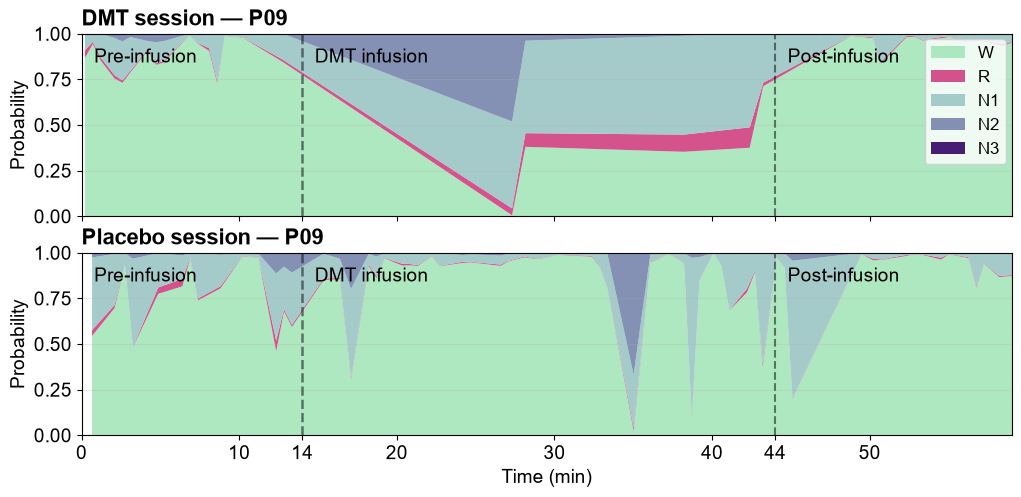

In [208]:
def plot_figure2a_from_csv(csv_path, subjects_to_plot=None, max_time_seconds=3540):
    """Recreate Fig. 2a directly from an exported figure2a CSV."""
    csv_path = Path(csv_path)
    plot_data = pd.read_csv(csv_path)
    stages = ('W', 'R', 'N1', 'N2', 'N3')
    palette = ['#a5e6ba', '#d14081', '#9ac6c5', '#7785ac', '#360568']
    colors = dict(zip(stages, palette))
    probability_columns = [f'prob_{stage}' for stage in stages]
    required = {'subject', 'condition', 'session', 'time_min', *probability_columns}
    missing = required - set(plot_data.columns)
    if missing:
        raise ValueError(f'CSV is missing columns: {sorted(missing)}')

    if subjects_to_plot is None:
        subjects_to_plot = sorted(plot_data['subject'].unique())
    elif isinstance(subjects_to_plot, str):
        subjects_to_plot = [subjects_to_plot]

    figures = []
    for subject in subjects_to_plot:
        subject_data = plot_data.loc[plot_data['subject'].eq(subject)]
        if subject_data.empty:
            raise ValueError(f'{subject} is not present in {csv_path}.')

        fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True, sharey=True)
        for axis, condition in zip(axes, ('DMT', 'placebo')):
            trajectory = subject_data.loc[subject_data['condition'].eq(condition)].sort_values('time_min')
            if trajectory.empty:
                raise ValueError(f'{subject} has no {condition} data in {csv_path}.')
            axis.stackplot(
                trajectory['time_min'],
                *[trajectory[column] for column in probability_columns],
                labels=stages,
                colors=[colors[stage] for stage in stages],
                alpha=0.9,
            )
            condition_title = condition.capitalize() if condition == 'placebo' else condition
            axis.axvline(x=experimental_windows_min['after'][0], color='k', linestyle='--', linewidth=1.8, alpha=0.5)
            axis.axvline(x=experimental_windows_min['after'][1], color='k', linestyle='--', linewidth=1.5, alpha=0.5)
            axis.text(x=0.8, y=0.92, s='Pre-infusion', fontsize = 14, rotation=0, va='top', ha='left')
            axis.text(x=experimental_windows_min['after'][0] + 0.8 , y=0.92, s='DMT infusion', fontsize = 14, rotation=0, va='top', ha='left')
            axis.text(x=experimental_windows_min['after'][1] + 0.8, y=0.92, s='Post-infusion', fontsize = 14, rotation=0, va='top', ha='left')
            axis.set_title(f'{condition_title} session — {subject}', loc='left', fontweight='bold', fontsize=16)
            axis.set_ylabel('Probability', fontsize = 14)
            axis.set_ylim(0, 1)
            axis.grid(axis='y', alpha=0.25)

        axes[-1].set_xlabel('Time (min)', fontsize = 14)
        axes[-1].set_xticks([0, 10, experimental_windows_min['after'][0], 20, 30, 40, experimental_windows_min['after'][1], 50, 60])
        axes[-1].set_xlim(0, max_time_seconds / 60)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, ncols=1, loc='upper right', bbox_to_anchor=(0.902, 0.845))
        fig.subplots_adjust(top=0.84)
        figures.append(fig)
        fig.savefig(output_dir / f'figure2a_{subject}.svg', dpi=300, bbox_inches='tight')
        print(f"Figure saved to {output_dir / f'figure2a_{subject}.svg'}")
    plt.show()
    return figures

# Example, after creating the CSV in the preceding cell:
figures = plot_figure2a_from_csv(figure_data_path, subjects_to_plot='P09')



### Fig 2. b. Example Power Spectral Density (PSD) of DMT and Placebo sessions for the same subject

Subjects included: ['P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P17', 'P18', 'P19', 'P21', 'P22', 'P23', 'P24', 'P26', 'P28']


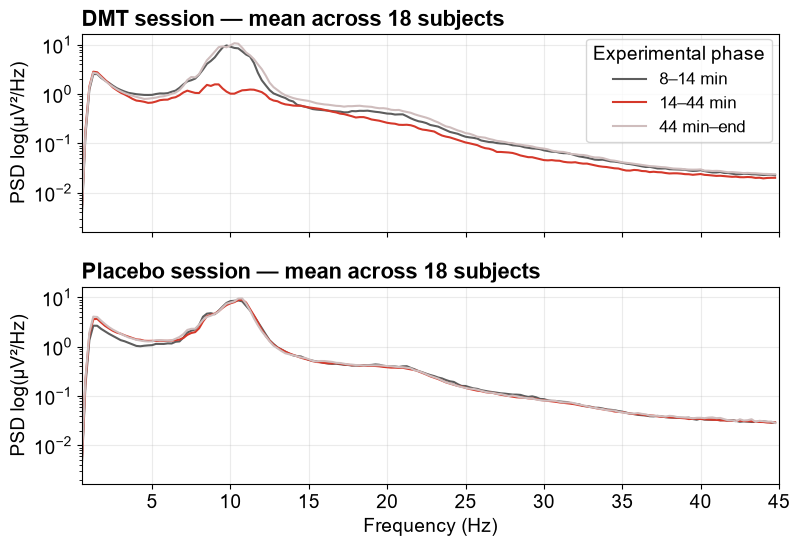

In [ ]:
# Fig. 2b — phase-specific PSDs for one participant
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PSD_RECORDINGS_DIR = Path(
    'D:/DMT_data/last results/02_hypnodensity_psd_000s/outputs/'
    'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1/recordings'
)
PSD_SESSIONS_BY_CONDITION = {'placebo': ('D1',), 'DMT': ('D5', 'D2')}
FREQUENCY_RANGE_HZ = (0.5, 45)

# The intervals are [8, 14), [14, 44), and [44, end) minutes.
PHASES = ('8–14 min', '14–44 min', '44 min–end')
PHASE_BINS_MIN = (8, 14, 44, np.inf)
PHASE_COLORS = {'8–14 min': '#5d5d5dff', '14–44 min': '#d5382aff', '44 min–end': '#cfbdbdff'}

if not PSD_RECORDINGS_DIR.is_dir():
    raise FileNotFoundError(f'Recordings directory not found: {PSD_RECORDINGS_DIR}')

def find_psd_recording(subject, condition, sessions, suffix):
    """Find one session, preferring the earlier entries in ``sessions``."""
    for session in sessions:
        matches = sorted(PSD_RECORDINGS_DIR.glob(f'*{subject}{session}*{suffix}'))
        if len(matches) == 1:
            return matches[0], session
        if len(matches) > 1:
            raise FileNotFoundError(
                f'Expected one {condition} {suffix} file for {subject}{session}; found: {matches}'
            )
    attempted = ', '.join(f'{subject}{session}' for session in sessions)
    raise FileNotFoundError(f'No {condition} {suffix} file found; tried: {attempted}')

def load_phase_psd(subject, condition):
    spectrum_path, session = find_psd_recording(
        subject, condition, PSD_SESSIONS_BY_CONDITION[condition], '_spectra.parquet'
    )
    hypnodensity_path, _ = find_psd_recording(
        subject, condition, PSD_SESSIONS_BY_CONDITION[condition], '_hypnodensities.parquet'
    )

    # Spectra have no timestamps. Hypnodensity rows provide one absolute start time
    # per block/epoch, regardless of stager or electrode.
    epoch_times = pd.read_parquet(
        hypnodensity_path, columns=['block_id', 'epoch', 'absolute_start']
    ).drop_duplicates()
    if epoch_times.duplicated(['block_id', 'epoch']).any():
        raise ValueError(f'A block/epoch maps to more than one time in {hypnodensity_path.name}.')

    spectra = pd.read_parquet(
        spectrum_path, columns=['recording_id', 'block_id', 'epoch', 'electrode', 'frequency_hz', 'power']
    )
    spectra = spectra.merge(epoch_times, on=['block_id', 'epoch'], how='inner', validate='many_to_one')
    spectra['phase'] = pd.cut(
        spectra['absolute_start'] / 60, bins=PHASE_BINS_MIN, labels=PHASES, right=False
    )
    spectra = spectra.loc[
        spectra['phase'].notna() & spectra['frequency_hz'].between(*FREQUENCY_RANGE_HZ)
    ]
    if spectra.empty:
        raise ValueError(f'No spectra from {FREQUENCY_RANGE_HZ} Hz fall within the requested phases.')

    # Mean PSD across all available epochs and electrodes in each phase.
    phase_psd = (
        spectra.groupby(['phase', 'frequency_hz'], observed=True, as_index=False)['power']
        .mean()
        .sort_values(['phase', 'frequency_hz'])
    )
    return phase_psd, spectrum_path.stem.removesuffix('_spectra'), session

print(f"Subjects included: {subjects}")

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, sharey=True)

for axis, condition in zip(axes, ("DMT", "placebo")):
    subject_psds = []

    for subject in subjects:
        phase_psd, _, _ = load_phase_psd(subject, condition)

        # Keep one PSD curve per subject before averaging subjects
        subject_psds.append(
            phase_psd.assign(subject=subject)
        )

    all_subject_psds = pd.concat(subject_psds, ignore_index=True)

    summary_phase_psd = (
    all_subject_psds
    .groupby(["phase", "frequency_hz"], observed=True)["power"]
    .agg(mean="mean", std="std")
    .reset_index()
    .sort_values(["phase", "frequency_hz"])
)

    for phase in PHASES:
        values = summary_phase_psd.loc[
            summary_phase_psd["phase"].eq(phase)
        ]

        frequency = values["frequency_hz"]
        mean = values["mean"]
        std = values["std"].fillna(0)

        axis.plot(
            frequency,
            mean,
            color=PHASE_COLORS[phase],
            label=phase,
            linewidth=1.5,
        )

        axis.fill_between(
            frequency,
            mean - std,
            mean + std,
            color=PHASE_COLORS[phase],
            alpha=0.2,
            linewidth=0,
        )

    title = condition.capitalize() if condition == "placebo" else condition
    axis.set_title(
        f"{title} session — mean across {len(subject_psds)} subjects",
        loc="left",
        fontweight="bold",
    )mean
    axis.set_ylabel("PSD log(µV²/Hz)")
    axis.grid(alpha=0.25)

axes[-1].set_xlabel("Frequency (Hz)")
axes[-1].set_yscale("log")
axes[-1].set_xlim(*FREQUENCY_RANGE_HZ)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Experimental phase",
    loc="upper right",
    bbox_to_anchor=(0.901, 0.866),
)

fig.subplots_adjust(top=0.86, hspace=0.28)
plt.show()